# VocEd Lab 03 — Image Processing: Denoising & Morphology

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emilsar/VocEd/blob/main/03_image_processing.ipynb)

In Lab 02 we found the best possible threshold pair using Bayesian optimisation.  But the
optimiser was limited by the raw grayscale representation — if two classes overlap in
intensity, no threshold can cleanly separate them.

What if we **cleaned the image first** before thresholding?  Classical image processing
offers several tools: smoothing to remove noise, and morphological operations to clean up
the predicted mask.  This lab explores whether they actually help.

By the end of this lab you will be able to:
- Apply Gaussian blur and non-local means denoising to an image.
- Apply morphological opening and closing to a segmentation mask.
- Combine these steps into a configurable pipeline controlled by boolean toggles.
- Re-run Bayesian optimisation on the extended parameter space and compare results.
- Interpret a cumulative Dice comparison table across Labs 01–03.

## 0. Setup

In [1]:
!pip install scikit-optimize scikit-image --quiet

# Clone the repo
!git clone https://github.com/emilsar/VocEd.git
%cd VocEd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 1.1 MB/s eta 0:00:00
Cloning into 'VocEd'...
remote: Enumerating objects: 663, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 663 (delta 55), reused 67 (delta 30), pack-reused 566 (from 1)
Receiving objects: 100% (663/663), 34.36 MiB | 17.86 MiB/s, done.
Resolving deltas: 100% (397/397), done.
Updating files: 100% (417/417), done.
/content/VocEd


## 1. Load Data & Recreate the Train/Test Split

In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split

N = len(glob.glob('imagedata/X/*.npy'))
X = np.stack([np.load(f'imagedata/X/{i}.npy') for i in range(N)])
y = np.stack([np.load(f'imagedata/y/{i}.npy') for i in range(N)])

# Drop images with no nucleus pixels — identical to Lab 02
has_nucleus = (y == 2).sum(axis=(1, 2)) > 0
X, y = X[has_nucleus], y[has_nucleus]
N = len(X)

# Stratified split by N/C ratio — identical to Lab 02
# N/C ratio = nucleus pixels / cytoplasm pixels is size-invariant, so the split
# is not biased by images that are simply larger.
nuc_px   = (y == 2).sum(axis=(1, 2))
cyt_px   = (y == 1).sum(axis=(1, 2))
nc_ratio = nuc_px / np.maximum(cyt_px, 1)   # np.maximum avoids div-by-zero
quartile = np.digitize(nc_ratio, np.percentile(nc_ratio, [25, 50, 75]))

train_idx, test_idx = train_test_split(
    np.arange(N), test_size=0.2, stratify=quartile, random_state=42
)

mask_cmap = ListedColormap(['black', 'steelblue', 'crimson'])
legend_patches = [
    mpatches.Patch(color='black',     label='0 — background'),
    mpatches.Patch(color='steelblue', label='1 — cytoplasm'),
    mpatches.Patch(color='crimson',   label='2 — nucleus'),
]
print(f'{N} images retained  ({(~has_nucleus).sum()} with no nucleus removed)')
print(f'Train: {len(train_idx)}   Test: {len(test_idx)}')

191 images retained  (9 with no nucleus removed)
Train: 152   Test: 39


## 2. Techniques Overview

We will test four classical image processing steps.  Each one is shown visually below with
a before/after comparison on image 7.

### Pre-threshold: image denoising

**Gaussian blur** — replaces each pixel with a weighted average of its neighbours.
Nearby pixels get higher weights; distant pixels get lower weights.  The result is a
smoother image with reduced noise, but also reduced sharpness.

**Non-local means** — instead of averaging a small neighbourhood, it searches the *entire*
image for patches that look similar to the current patch, and averages those.  This
preserves edges much better than Gaussian blur, but is slower to compute.

### Post-threshold: morphological operations

**Opening** (erode then dilate) — shrinks bright regions first (erosion), then grows them
back (dilation).  Small isolated bright blobs disappear because they get eroded away
entirely before dilation can restore them.

**Closing** (dilate then erode) — grows bright regions first, then shrinks them.  Small
holes inside bright regions get filled in by dilation before erosion can re-open them.

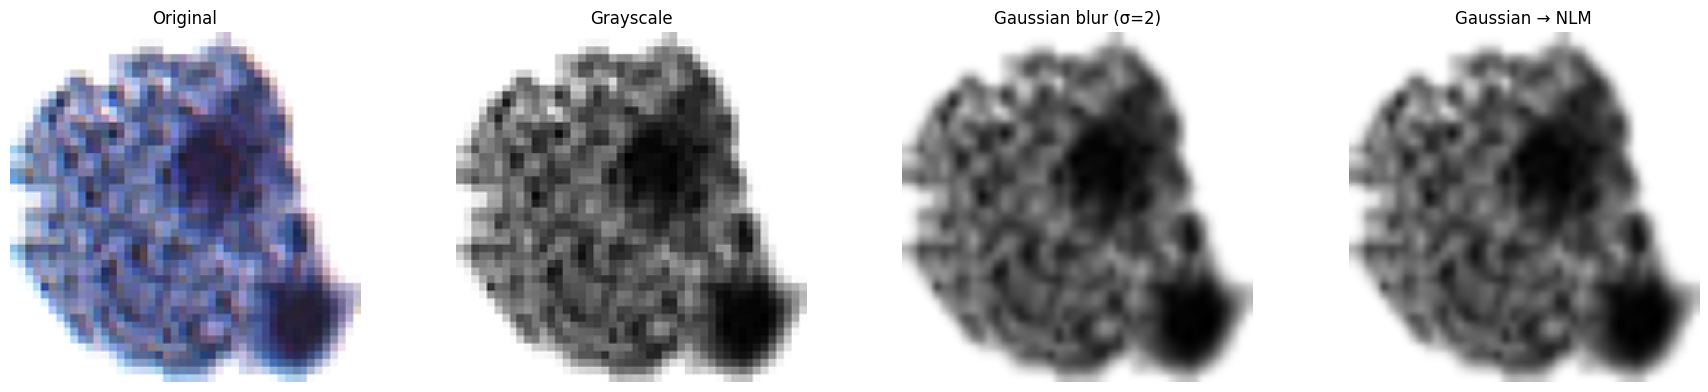

In [3]:
import skimage.filters as skf
import skimage.restoration as skr
import skimage.morphology as skm

IDX = 7
img = X[IDX]   # (3, 256, 256)

# Rearrange to (H, W, C) for display
img_hwc = img.transpose(1, 2, 0)   # (256, 256, 3)

# Luminance-weighted grayscale — reused throughout the pipeline
def to_gray(img):
    return 0.299 * img[0] + 0.587 * img[1] + 0.114 * img[2]

# ── Step 1: Grayscale ──────────────────────────────────────────────────────────
gray = to_gray(img)   # (256, 256)

# ── Step 2: Gaussian blur ──────────────────────────────────────────────────────
# sigma controls the width of the blur kernel; higher = more blurring
blurred = skf.gaussian(gray, sigma=2)

# ── Step 3: Non-local means on the blurred grayscale ──────────────────────────
# estimate_sigma measures the residual noise in the blurred image;
# h = 3 * sigma_est sets the NLM filter strength proportionally
sigma_est = np.mean(skr.estimate_sigma(blurred))
nlm = skr.denoise_nl_means(blurred, h=3 * sigma_est,
                            patch_size=8, patch_distance=10)

# ── Show all four steps ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(img_hwc);                          axes[0].set_title('Original');            axes[0].axis('off')
axes[1].imshow(gray,    cmap='gray');             axes[1].set_title('Grayscale');           axes[1].axis('off')
axes[2].imshow(blurred, cmap='gray');             axes[2].set_title('Gaussian blur (σ=2)'); axes[2].axis('off')
axes[3].imshow(np.clip(nlm, 0, 1), cmap='gray'); axes[3].set_title('Gaussian → NLM');      axes[3].axis('off')
plt.tight_layout()
plt.show()

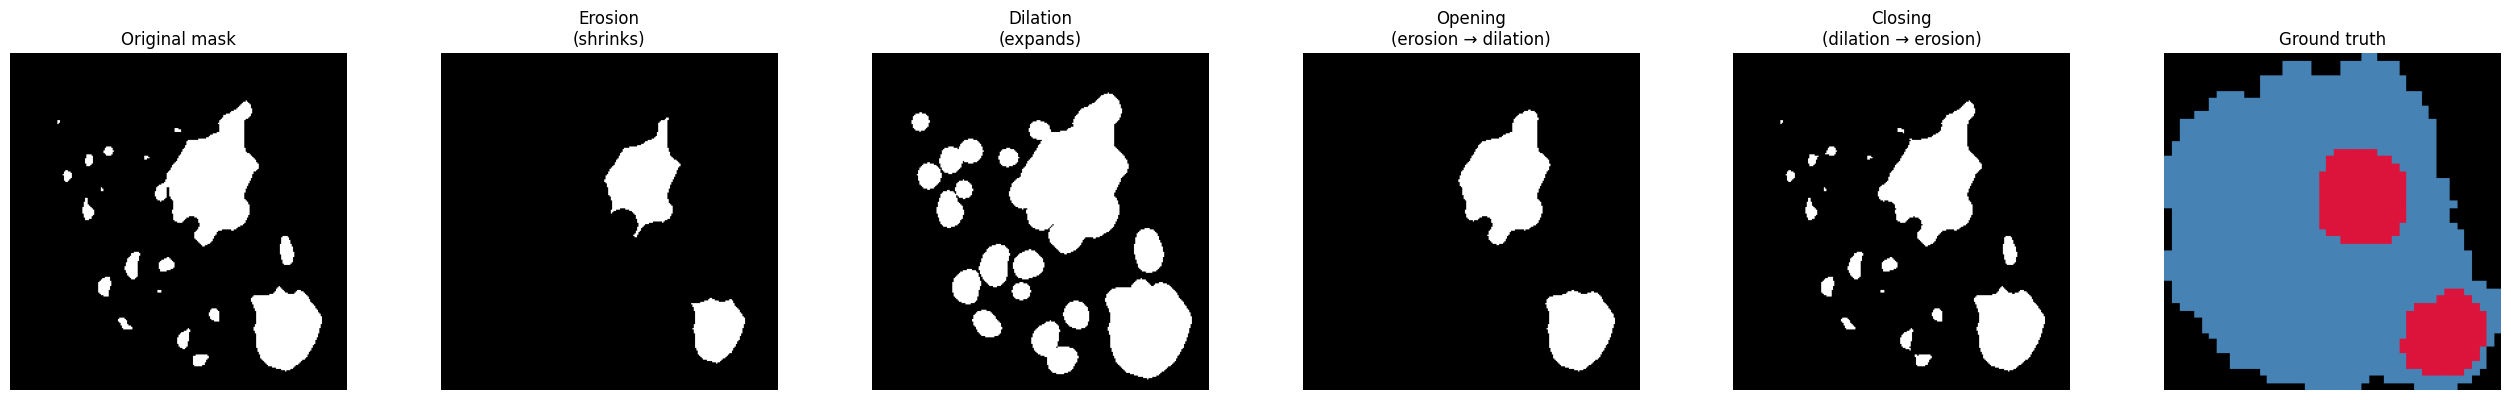

In [4]:
# ── Morphological operations on a nucleus mask ─────────────────────────────────
# Nucleus pixels are the darkest — threshold below 0.29 captures them as
# foreground (white = 1).  Everything brighter (cytoplasm, background) is
# background (black = 0).
nucleus_mask = (nlm < 0.29).astype(bool)

# disk(6) creates a circular structuring element with radius 6 pixels
# — this is the "neighbourhood" used by erode/dilate
disk = skm.disk(6)

eroded  = skm.erosion(nucleus_mask, disk)    # shrinks foreground
dilated = skm.dilation(nucleus_mask, disk)   # expands foreground
opened  = skm.opening(nucleus_mask, disk)    # erosion → dilation: removes small blobs
closed  = skm.closing(nucleus_mask, disk)    # dilation → erosion: fills small holes

fig, axes = plt.subplots(1, 6, figsize=(26, 4))
axes[0].imshow(nucleus_mask, cmap='gray');  axes[0].set_title('Original mask');                   axes[0].axis('off')
axes[1].imshow(eroded,       cmap='gray');  axes[1].set_title('Erosion\n(shrinks)');              axes[1].axis('off')
axes[2].imshow(dilated,      cmap='gray');  axes[2].set_title('Dilation\n(expands)');             axes[2].axis('off')
axes[3].imshow(opened,       cmap='gray');  axes[3].set_title('Opening\n(erosion → dilation)');  axes[3].axis('off')
axes[4].imshow(closed,       cmap='gray');  axes[4].set_title('Closing\n(dilation → erosion)');  axes[4].axis('off')
axes[5].imshow(y[IDX], cmap=mask_cmap, vmin=0, vmax=2); axes[5].set_title('Ground truth');       axes[5].axis('off')
plt.tight_layout()
plt.show()

## 3. The Configurable Pipeline

We now build a single `full_pipeline` function with boolean flags for each step.  Turning
a flag off (False) skips that step entirely and passes the image/mask through unchanged.
This makes it easy to ablate each component.

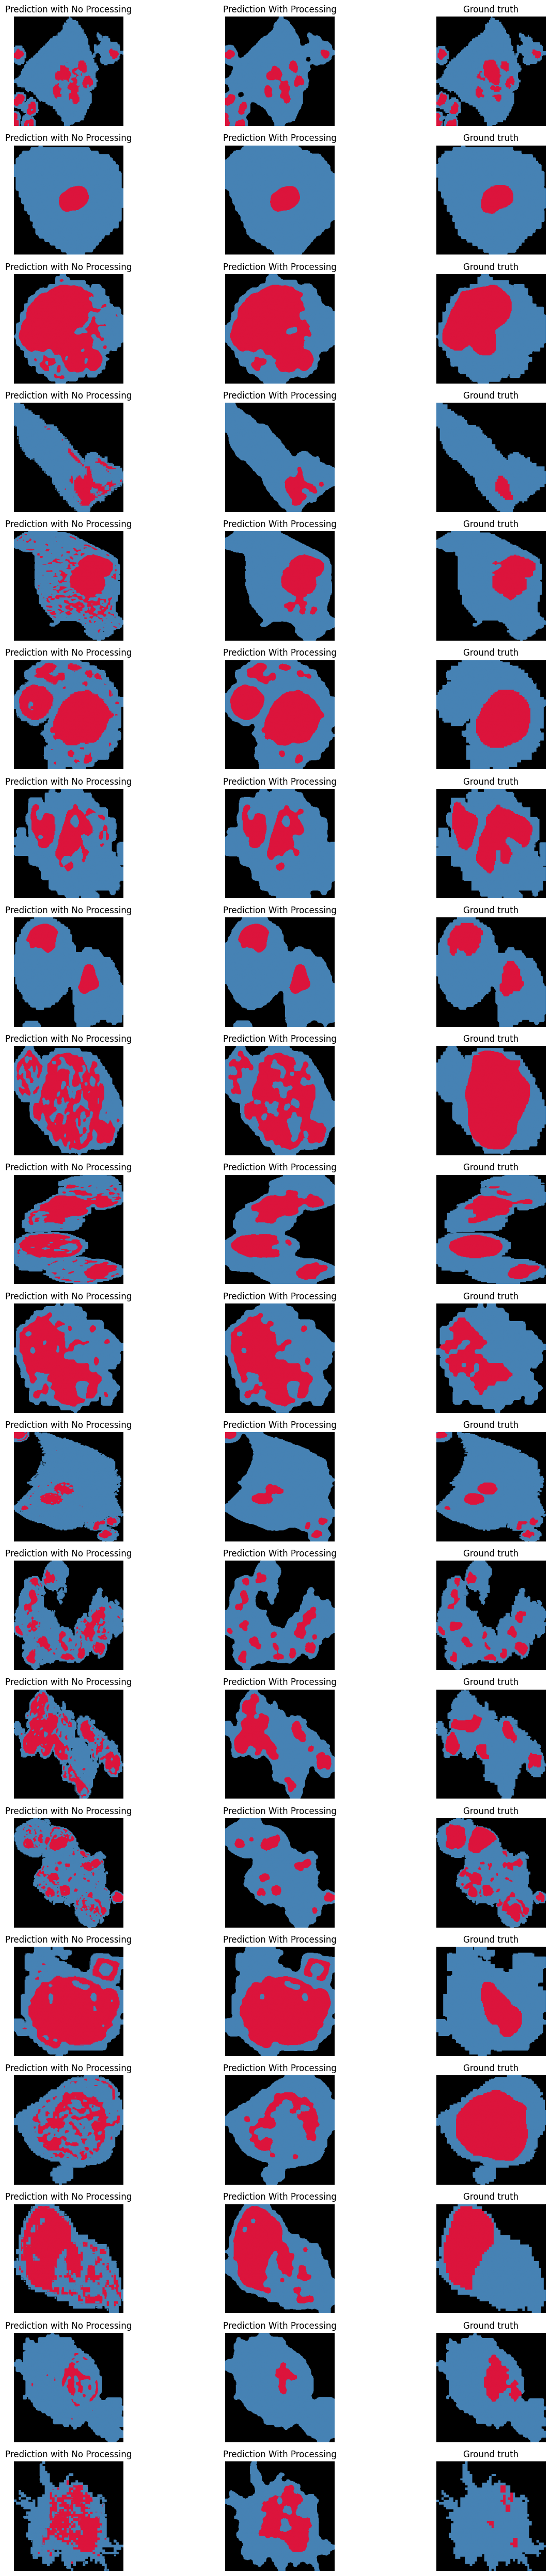

In [5]:

def full_pipeline(img, t_nucleus, t_background,
                  use_blur=True, use_nlm=True,
                  use_open=False, use_close=True,
                  blur_sigma=1.5, morph_radius=5):
    """
    Full segmentation pipeline with optional denoising and morphological steps.

    img            : (3, H, W) float32 image
    t_nucleus      : pixels darker than this → nucleus
    t_background   : pixels brighter than this → background
    use_blur       : apply Gaussian blur before thresholding
    use_nlm        : apply non-local means before thresholding
    use_open       : apply morphological opening after thresholding
    use_close      : apply morphological closing after thresholding
    blur_sigma     : sigma for Gaussian blur
    morph_radius   : radius of the disk structuring element
    """
    img_hwc = img.transpose(1, 2, 0)   # convert to (H, W, C) for skimage

    # ── Step 1: optional pre-threshold denoising ──────────────────────────────
    if use_blur:
        img_hwc = skf.gaussian(img_hwc, sigma=blur_sigma, channel_axis=-1)

    if use_nlm:
        sig = np.mean(skr.estimate_sigma(img_hwc, channel_axis=-1))
        img_hwc = skr.denoise_nl_means(img_hwc, h=0.8 * sig,
                                        patch_size=5, patch_distance=6,
                                        channel_axis=-1)

    # ── Step 2: grayscale + threshold ─────────────────────────────────────────
    gray = 0.299 * img_hwc[:,:,0] + 0.587 * img_hwc[:,:,1] + 0.114 * img_hwc[:,:,2]
    pred = np.zeros(gray.shape, dtype=np.int64)
    pred[gray < t_nucleus]                                = 2
    pred[(gray >= t_nucleus) & (gray < t_background)]    = 1

    # ── Step 3: optional post-threshold morphology ────────────────────────────
    if use_open or use_close:
        disk = skm.disk(morph_radius)
        for cls in [1, 2]:                          # process cytoplasm and nucleus separately
            cls_mask = (pred == cls).astype(bool)

            if use_open:
                cls_mask = skm.opening(cls_mask, disk)

            if use_close:
                cls_mask = skm.closing(cls_mask, disk)

            pred[pred == cls] = 0                   # clear the class pixels
            pred[cls_mask]    = cls                 # write back the cleaned mask

    return pred


# Sanity check: run pipeline on random 20 images.  Just type sanity() below to run this function
def sanity():
  fig, axes = plt.subplots(20, 3, figsize=(14, 50))

  for i in range(20):
      rng = np.random.default_rng()
      idx = rng.choice(len(train_idx))

      axes[i, 0].imshow(full_pipeline(X[idx], t_nucleus=0.39, t_background=0.99,
                                      use_blur=False, use_nlm=False,
                                      use_open=False, use_close=False,
                                      blur_sigma=1.5, morph_radius=5), cmap=mask_cmap)

      axes[i, 0].set_title("Prediction with No Processing")
      axes[i, 0].axis('off')


      axes[i, 1].imshow(full_pipeline(X[idx], t_nucleus=0.39, t_background=0.99,
                                      use_blur=True, use_nlm=True,
                                      use_open=False, use_close=True,
                                      blur_sigma=1.5, morph_radius=5), cmap=mask_cmap)

      axes[i, 1].set_title('Prediction With Processing')
      axes[i, 1].axis('off')

      axes[i, 2].imshow(y[idx], cmap=mask_cmap)
      axes[i, 2].set_title('Ground truth')
      axes[i, 2].axis('off')

  plt.tight_layout()
  plt.show()

sanity()

## 4. Bayesian Optimisation with All Steps Enabled

We now run Bayesian optimisation over a larger parameter space that includes all optional
steps turned on.  We treat the five continuous parameters — `t_nucleus`, `t_background`,
`blur_sigma`, and `morph_radius` — as the search variables, with the boolean flags fixed
to `True` (all steps enabled).  This tests whether the combined pipeline can beat pure
threshold optimisation.

In [6]:
from skopt import gp_minimize
from skopt.space import Real, Integer

def dice_score(pred, target, cls):
    pred_mask   = (pred   == cls)
    target_mask = (target == cls)
    intersection = (pred_mask & target_mask).sum()
    denom = pred_mask.sum() + target_mask.sum()
    return 1.0 if denom == 0 else 2 * intersection / denom


def mean_dice_pipeline(indices, t_nucleus, t_background,
                        use_blur, use_nlm, use_open, use_close,
                        blur_sigma=1.5, morph_radius=3):
    """Mean Dice over a list of image indices using the full pipeline."""
    scores = []
    for i in indices:
        pred = full_pipeline(X[i], t_nucleus, t_background,
                             use_blur=use_blur, use_nlm=use_nlm,
                             use_open=use_open, use_close=use_close,
                             blur_sigma=blur_sigma, morph_radius=morph_radius)
        d = (dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2
        scores.append(d)
    return np.mean(scores)


# ── Objective: optimise over 4 continuous parameters, all steps enabled ───────
def objective_full(params):
    t_nuc, t_bg, sigma, radius = params
    return -mean_dice_pipeline(
        train_idx, t_nuc, t_bg,
        use_blur=True, use_nlm=False,   # NLM is slow; use blur for the automated search
        use_open=True, use_close=True,
        blur_sigma=sigma, morph_radius=int(radius)
    )


search_space_full = [
    Real(0.10, 0.70, name='t_nucleus'),
    Real(0.50, 0.99, name='t_background'),
    Real(0.5,  3.0,  name='blur_sigma'),
    Real(1,    5,    name='morph_radius'),
]

print('Running Bayesian optimisation with full pipeline (50 evals)...')
result_full = gp_minimize(
    func=objective_full,
    dimensions=search_space_full,
    n_calls=50,
    n_initial_points=10,
    random_state=42,
    verbose=False,
)
print('Done.')

best_nuc_full, best_bg_full, best_sigma, best_radius = result_full.x
print(f'Best params: t_nuc={best_nuc_full:.4f}  t_bg={best_bg_full:.4f}  '
      f'sigma={best_sigma:.2f}  radius={best_radius:.1f}')
print(f'Train Dice: {-result_full.fun:.4f}')

Running Bayesian optimisation with full pipeline (50 evals)...
Done.
Best params: t_nuc=0.4013  t_bg=0.9900  sigma=0.98  radius=2.0
Train Dice: 0.7818


## 5. Cumulative Comparison Table — Labs 01, 02, 03

We record the test-set Dice for each method so far.  We will extend this table in every
subsequent lab.

In [7]:
# Lab 01 baseline (hand-picked)
def segment_plain(img, t_nucleus, t_background):
    gray = to_gray(img)
    pred = np.zeros(gray.shape, dtype=np.int64)
    pred[gray < t_nucleus]                                = 2
    pred[(gray >= t_nucleus) & (gray < t_background)]    = 1
    return pred

def train_dice(pred_fn):
    scores = []
    for i in train_idx:
        pred = pred_fn(i)
        d = (dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2
        scores.append(d)
    return np.mean(scores)

def test_dice(pred_fn):
    scores = []
    for i in test_idx:
        pred = pred_fn(i)
        d = (dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2
        scores.append(d)
    return np.mean(scores)

# Lab 01: hand-picked thresholds (no optimisation, so train ≈ test expected)
d_lab01_train = train_dice(lambda i: segment_plain(X[i], 0.45, 0.85))
d_lab01_test  = test_dice( lambda i: segment_plain(X[i], 0.45, 0.85))

# Lab 02: Bayesian-optimised thresholds
# (re-run the Lab 02 optimisation with n_calls=50 to get the same result)
def objective_lab02(params):
    t_nuc, t_bg = params
    scores = []
    for i in train_idx:
        pred = segment_plain(X[i], t_nuc, t_bg)
        d = (dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2
        scores.append(d)
    return -np.mean(scores)

from skopt.space import Real
from skopt import gp_minimize

res02 = gp_minimize(objective_lab02,
                    [Real(0.10, 0.70), Real(0.50, 0.99)],
                    n_calls=50, n_initial_points=10, random_state=42, verbose=False)
# -res02.fun is the train Dice at the best params (already computed by the optimiser)
d_lab02_train = -res02.fun
d_lab02_test  = test_dice(lambda i: segment_plain(X[i], res02.x[0], res02.x[1]))

# Lab 03: full pipeline with optimised params
# -result_full.fun is the train Dice at the best params (already computed above)
d_lab03_train = -result_full.fun
d_lab03_test  = test_dice(
    lambda i: full_pipeline(X[i],
                            best_nuc_full, best_bg_full,
                            use_blur=True, use_nlm=False,
                            use_open=True, use_close=True,
                            blur_sigma=best_sigma,
                            morph_radius=int(best_radius))
)

# For low-capacity models (a few global parameters), train ≈ test is expected:
# the optimal threshold describes the whole dataset's intensity distribution, not
# training-specific patterns.  A large train/test gap only appears with high-capacity
# models (neural networks) that can memorise individual training images.
print('=' * 68)
print(f'{"Method":<36}  {"Train Dice":>10}  {"Test Dice":>10}')
print('-' * 68)
print(f'{"Lab 01 — hand-picked thresholds":<36}  {d_lab01_train:10.4f}  {d_lab01_test:10.4f}')
print(f'{"Lab 02 — Bayesian opt thresholds":<36}  {d_lab02_train:10.4f}  {d_lab02_test:10.4f}')
print(f'{"Lab 03 — Bayesian opt + pipeline":<36}  {d_lab03_train:10.4f}  {d_lab03_test:10.4f}')
print('=' * 68)


Method                                Train Dice   Test Dice
--------------------------------------------------------------------
Lab 01 — hand-picked thresholds           0.7125      0.7441
Lab 02 — Bayesian opt thresholds          0.7772      0.8199
Lab 03 — Bayesian opt + pipeline          0.7818      0.8227


## Wrap-up

**Key takeaways:**
- Denoising and morphology can help at the margins — they reduce noise artefacts and clean
  up ragged mask boundaries.
- But the improvements are small.  The fundamental bottleneck is that two classes overlap
  in grayscale intensity; no amount of pre-processing fully resolves that.
- In the next lab we move past grayscale entirely: we will treat each pixel as a vector of
  **3 colour values** and train a classifier to separate them.

---

## Group Exercise — Ablation Study

An *ablation study* measures how much each component of a system contributes by removing
it and measuring the drop in performance.

Your group will test the pipeline on **5 images** (`test_idx[0:5]`) with each toggle.
Use the optimised thresholds from Lab 02 (`res02.x[0]` and `res02.x[1]`) throughout.

| Person | Toggle to test |
|---|---|
| A | `use_blur=True`, all others `False` |
| B | `use_open=True`, all others `False` |
| C | `use_close=True`, all others `False` |

For each toggle, record the mean Dice on those 5 images and the Dice delta vs the baseline
(no processing).  Share results and discuss: which step helps most, and why?

## 6. N/C Ratio Scatter — Predicted vs True

A Dice score tells us how well the *shape* of the mask overlaps.  The **N/C ratio**
(nucleus area ÷ cytoplasm area) is the clinically relevant quantity — it is elevated in
malignant cells and used as a diagnostic feature.

Here we ask: even if our segmentation is not pixel-perfect, does it at least reproduce the
correct N/C ratio?  A scatter plot of predicted vs true N/C ratio, with y = x as a
reference, answers this directly.  We summarise each panel with
**R² vs y = x** — the coefficient of determination against the identity line:

$$R^2 = 1 - \frac{\sum_i(\hat{y}_i - y_i)^2}{\sum_i(y_i - \bar{y})^2}$$

R² = 1 is perfect; it falls with any deviation from the identity line, whether by
systematic bias or random scatter.

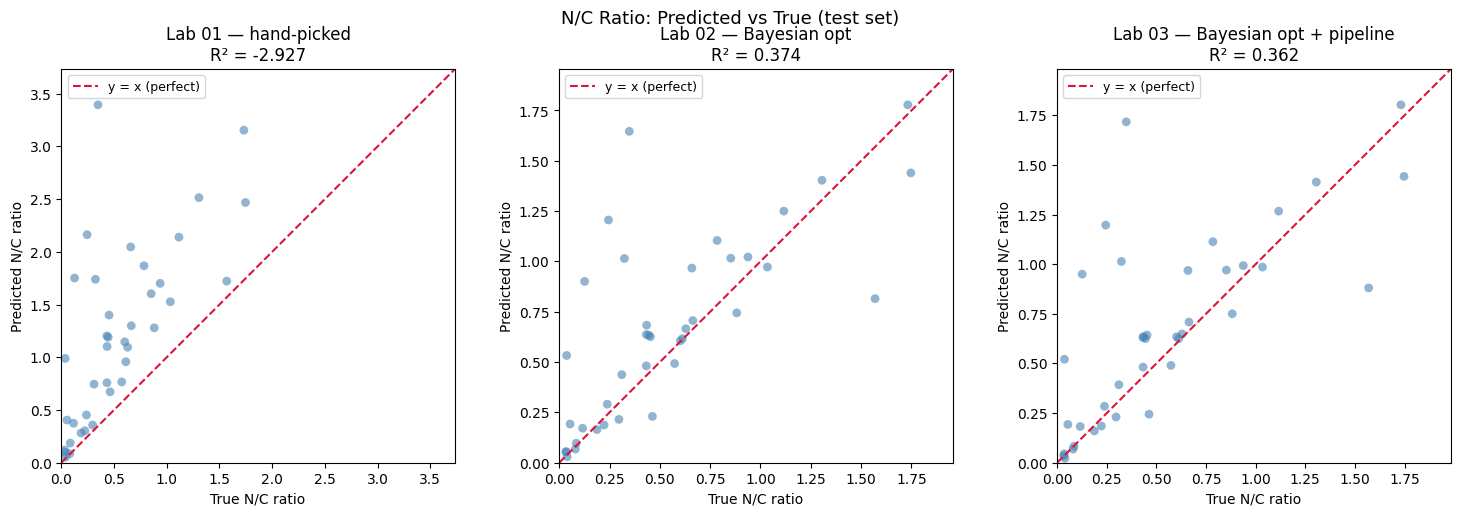

In [8]:
def nc_ratio(mask):
    """
    N/C ratio: nucleus pixel count / cytoplasm pixel count.
    Returns nan if there are no cytoplasm pixels (ratio undefined).
    """
    nuc = (mask == 2).sum()
    cyt = (mask == 1).sum()
    return nuc / cyt if cyt > 0 else np.nan


# ── True N/C ratios from ground-truth masks ────────────────────────────────────────
nc_true = np.array([nc_ratio(y[i]) for i in test_idx])

# ── Predicted N/C ratios for each lab method ──────────────────────────────────
nc_lab01 = np.array([nc_ratio(segment_plain(X[i], 0.45, 0.85))
                     for i in test_idx])

nc_lab02 = np.array([nc_ratio(segment_plain(X[i], res02.x[0], res02.x[1]))
                     for i in test_idx])

nc_lab03 = np.array([nc_ratio(full_pipeline(X[i],
                                             best_nuc_full, best_bg_full,
                                             use_blur=True, use_nlm=False,
                                             use_open=True, use_close=True,
                                             blur_sigma=best_sigma,
                                             morph_radius=int(best_radius)))
                     for i in test_idx])

def r2_identity(yp, gt):
    """R² vs y = x: 1 means perfect agreement; falls with any deviation from the identity line."""
    ok = np.isfinite(yp) & np.isfinite(gt)
    p, g = yp[ok], gt[ok]
    ss_res = np.sum((p - g) ** 2)
    ss_tot = np.sum((g - g.mean()) ** 2)
    return 1 - ss_res / ss_tot

# ── Scatter plots: predicted vs true N/C ratio ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, nc_pred, label in zip(
        axes,
        [nc_lab01, nc_lab02, nc_lab03],
        ['Lab 01 — hand-picked', 'Lab 02 — Bayesian opt', 'Lab 03 — Bayesian opt + pipeline']):

    valid = np.isfinite(nc_true) & np.isfinite(nc_pred)
    x, yp = nc_true[valid], nc_pred[valid]
    r2 = r2_identity(nc_pred, nc_true)

    ax.scatter(x, yp, alpha=0.6, color='steelblue', edgecolors='none', s=40)
    lim = max(x.max(), yp.max()) * 1.1
    ax.plot([0, lim], [0, lim], color='crimson', linestyle='--',
            linewidth=1.5, label='y = x (perfect)')
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect('equal')
    ax.set_xlabel('True N/C ratio')
    ax.set_ylabel('Predicted N/C ratio')
    ax.set_title(f'{label}\nR² = {r2:.3f}')
    ax.legend(fontsize=9)

plt.suptitle('N/C Ratio: Predicted vs True (test set)', fontsize=13)
plt.tight_layout()
plt.show()